# Regression Modeling Imports

This cell imports all required functions and utilities for the regression modeling workflow.

### What is happening
- `run_train_test_split` prepares and saves the train/test datasets.
- `train_regression_models` trains all required regression models, evaluates them, ranks them, and saves artifacts.
- `find_project_root` and `resolve_project_path` help locate project folders/files consistently.
- `read_csv_file` is used to load saved CSV outputs such as `train.csv` and `test.csv`.

### Main files used later
- `data/processed/train.csv`
- `data/processed/test.csv`
- `artifacts/regression/...`
- `artifacts/comparison/...`
- `figures/regression/...`
- `reports/regression_evaluation_report.md`

In [1]:
from pathlib import Path

import pandas as pd

from src.data.split_data import run_train_test_split
from src.modeling.train_regression import train_regression_models
from src.utils.paths import find_project_root, resolve_project_path
from src.utils.io import read_csv_file

# Resolve Project Root

This cell identifies the project root directory.

### What is happening
- The notebook detects the top-level project folder so that all subsequent file reads/writes happen in the correct location.
- This avoids hardcoding file paths.

### Where this is used
All saved outputs later depend on this root path, including:
- `data/processed/`
- `artifacts/regression/`
- `artifacts/comparison/`
- `figures/regression/`
- `reports/`

In [2]:
project_root = find_project_root()
project_root

WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation')

# Create Train/Test Split

This cell runs the train/test split step for the regression-ready dataset.

### What is happening
- The regression modeling dataset is loaded from:
  - `data/processed/regression_model_input.csv`
- It is split into training and testing subsets.
- The split uses the configuration values defined earlier in the project.

### Files created
- `data/processed/train.csv`
- `data/processed/test.csv`

### Why this matters
These two files become the direct input for all regression model training and evaluation.

In [3]:
split_results = run_train_test_split(project_root)
split_results

2026-03-23 00:28:00,016 | INFO | src.data.split_data | Loading regression modeling dataset...
2026-03-23 00:28:00,154 | INFO | src.data.split_data | Splitting dataset into train/test...
2026-03-23 00:28:00,272 | INFO | src.data.split_data | Saving train/test splits...
2026-03-23 00:28:00,487 | INFO | src.data.split_data | Train/test split completed.


{'train_shape': (43152, 8),
 'test_shape': (10788, 8),
 'train_path': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/train.csv'),
 'test_path': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/test.csv')}

# Load and Inspect Train/Test Data

This cell loads the saved train and test CSV files and checks their shape and structure.

### What is happening
- The notebook reads:
  - `data/processed/train.csv`
  - `data/processed/test.csv`
- It prints the shape of each dataset.
- It displays the first few rows of the training set.

### Why this matters
This confirms that:
- the split completed successfully,
- the target column is still present,
- the selected raw + engineered features passed into modeling are available.

### Files being read
- `data/processed/train.csv`
- `data/processed/test.csv`

In [4]:
train_df = read_csv_file(resolve_project_path(project_root, "data/processed/train.csv"))
test_df = read_csv_file(resolve_project_path(project_root, "data/processed/test.csv"))

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (43152, 8)
Test shape: (10788, 8)


,volume,carat,depth,table,clarity,color,cut,price
0,321.515649,2.01,58.1,64.0,SI2,F,Good,16231
1,167.146056,1.01,60.0,60.0,SI2,E,Very Good,4540
2,176.704260,1.10,62.5,58.0,VS2,H,Premium,5729
3,228.494994,1.50,61.5,65.0,SI2,E,Good,6300
4,241.070292,1.52,62.1,57.0,VS1,G,Very Good,12968


# Train and Evaluate Regression Models

This is the main regression training cell.

### What is happening
The following models are trained:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- KNN Regressor
- XGBoost Regressor

For each model:
- preprocessing is applied,
- the model is trained on the training set,
- predictions are made on the test set,
- evaluation metrics are calculated.

Then:
- all models are compared,
- the best regression model is selected,
- artifacts are saved.

### Metrics computed
- MAE
- MSE
- RMSE
- R²

### Files created

#### Regression model artifacts
- `artifacts/regression/linear_regression_model.pkl`
- `artifacts/regression/decision_tree_regressor.pkl`
- `artifacts/regression/random_forest_regressor.pkl`
- `artifacts/regression/knn_regressor.pkl`
- `artifacts/regression/xgboost_regressor.pkl`
- `artifacts/regression/best_regression_model.pkl`
- `artifacts/regression/preprocessing_pipeline.pkl`
- `artifacts/regression/regression_metrics.csv`
- `artifacts/regression/regression_predictions.csv`
- `artifacts/regression/best_regression_model_metadata.yaml`

#### Comparison artifacts
- `artifacts/comparison/model_comparison_table.csv`
- `artifacts/comparison/experiment_tracking.csv`

#### Figures
- `figures/regression/actual_vs_predicted_best_model.png`
- `figures/regression/residual_plot_best_model.png`
- `figures/regression/regression_models_comparison.png`
- `figures/regression/random_forest_feature_importance.png`
  *(only if the winning model supports feature importance)*

#### Report
- `reports/regression_evaluation_report.md`

### Why this matters
This cell completes the full classical regression modeling stage of the project.

In [6]:
results = train_regression_models(project_root)

2026-03-23 00:36:54,922 | INFO | src.data.split_data | Loading regression modeling dataset...
2026-03-23 00:36:54,965 | INFO | src.data.split_data | Splitting dataset into train/test...
2026-03-23 00:36:54,976 | INFO | src.data.split_data | Saving train/test splits...
2026-03-23 00:36:55,173 | INFO | src.data.split_data | Train/test split completed.
2026-03-23 00:36:55,174 | INFO | src.modeling.train_regression | Train/test split ready: {'train_shape': (43152, 8), 'test_shape': (10788, 8), 'train_path': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/train.csv'), 'test_path': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/test.csv')}
2026-03-23 00:36:55,427 | INFO | src.modeling.train_regression | Training model: linear_regression
2026-03-23 00:36:55,861 | INFO | src.modeling.train_regression | Training model: decision_tree_regressor
2026-03-23 00:36:56,203 | I

# View Regression Metrics Table

This cell displays the evaluation table for all trained regression models.

### What is happening
- The saved metrics collected during training are shown as a dataframe.
- The models are ranked based on performance, typically with lower RMSE being better.

### What this helps you verify
- which model performed best,
- how close the models are to each other,
- whether the selected best model is justified.

### Source of this result
This table comes from the output of the regression training pipeline and is also saved to:
- `artifacts/regression/regression_metrics.csv`
- `artifacts/comparison/model_comparison_table.csv`

In [7]:
results["metrics_df"]

,mae,mse,rmse,r2,model_name,rank
0,274.759066,2.941781e+05,542.381907,0.981495,xgboost_regressor,1
1,279.889509,3.057254e+05,552.924423,0.980768,random_forest_regressor,2
2,358.366327,4.686911e+05,684.610156,0.970517,decision_tree_regressor,3
3,405.324480,6.022641e+05,776.056784,0.962114,knn_regressor,4
4,1855.892744,3.143733e+08,17730.574105,-18.775856,linear_regression,5


# View Prediction Results

This cell displays the prediction output dataframe.

### What is happening
The dataframe typically includes:
- model name,
- actual values,
- predicted values,
- residuals.

### Why this matters
This helps inspect:
- prediction quality,
- underprediction/overprediction patterns,
- model behavior on the test set.

### File where this is stored
- `artifacts/regression/regression_predictions.csv`

In [9]:
print(results["predictions_df"].head())
results["predictions_df"].tail()

          model_name  actual     predicted     residual
0  linear_regression   559.0    881.979580  -322.979580
1  linear_regression  2201.0   1921.678251   279.321749
2  linear_regression  1238.0   1323.166508   -85.166508
3  linear_regression  1304.0   1369.857590   -65.857590
4  linear_regression  6901.0  11143.195987 -4242.195987


,model_name,actual,predicted,residual
53935,xgboost_regressor,1554.0,1709.975586,-155.975586
53936,xgboost_regressor,633.0,578.732605,54.267395
53937,xgboost_regressor,761.0,750.972839,10.027161
53938,xgboost_regressor,9836.0,9771.330078,64.669922
53939,xgboost_regressor,3742.0,3623.192871,118.807129


# Identify the Best Regression Model

This cell shows the final best-performing regression model selected from the comparison stage.

### What is happening
- The top-ranked model name is extracted from the evaluation results.
- This is the model that gets saved as the final regression model artifact.

### Final model file
- `artifacts/regression/best_regression_model.pkl`

### Metadata file
- `artifacts/regression/best_regression_model_metadata.yaml`

In [10]:
best_model_name = results["best_model_name"]
best_model_name

'xgboost_regressor'

# Display Saved Regression Evaluation Plots

This cell loads and displays the saved regression evaluation figures.

### What is happening
The notebook displays:
- model comparison plot,
- actual vs predicted plot for the best model,
- residual plot for the best model.

### Files being displayed
- `figures/regression/regression_models_comparison.png`
- `figures/regression/actual_vs_predicted_best_model.png`
- `figures/regression/residual_plot_best_model.png`

### Why this matters
These visualizations help interpret:
- overall model ranking,
- how closely predictions follow actual values,
- residual spread and possible systematic error.

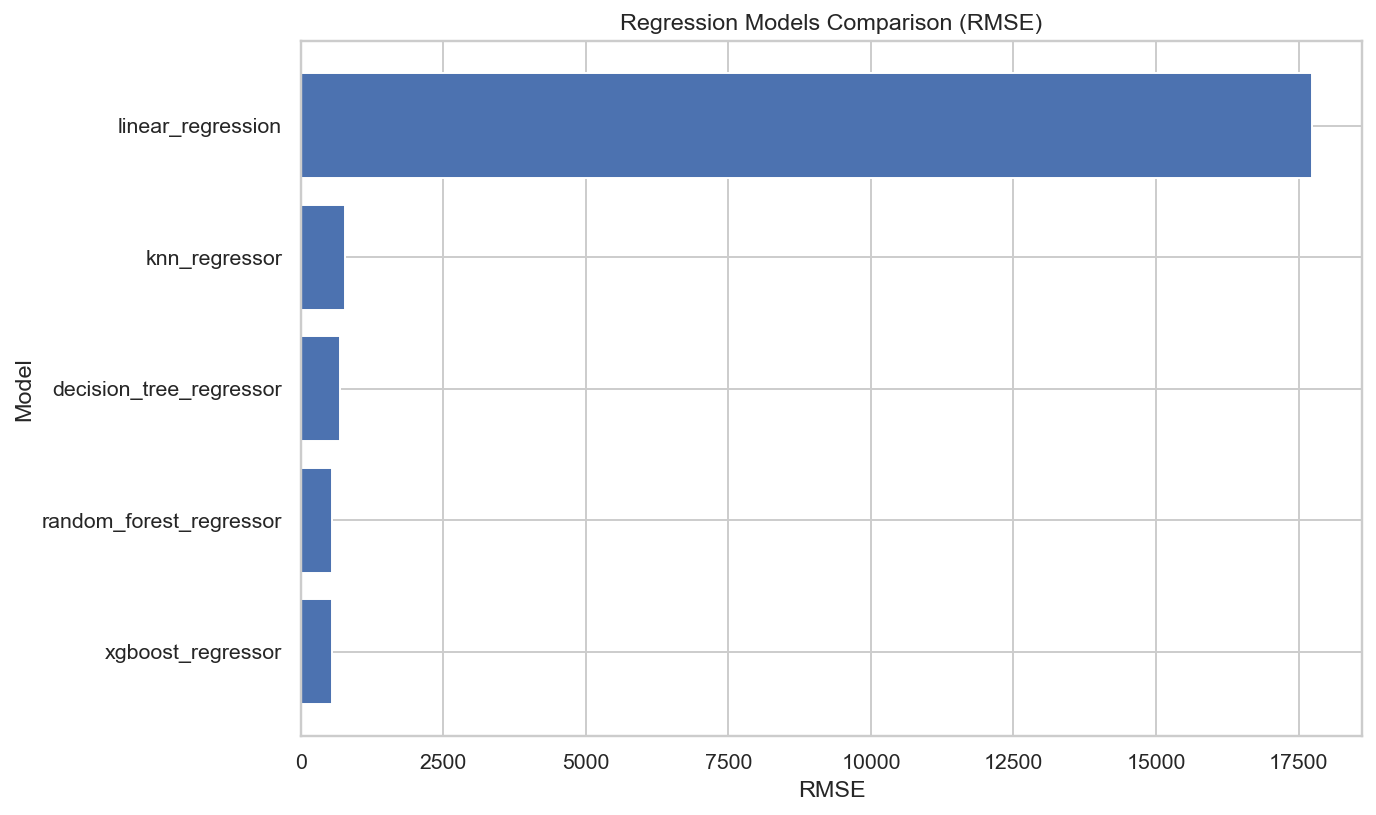

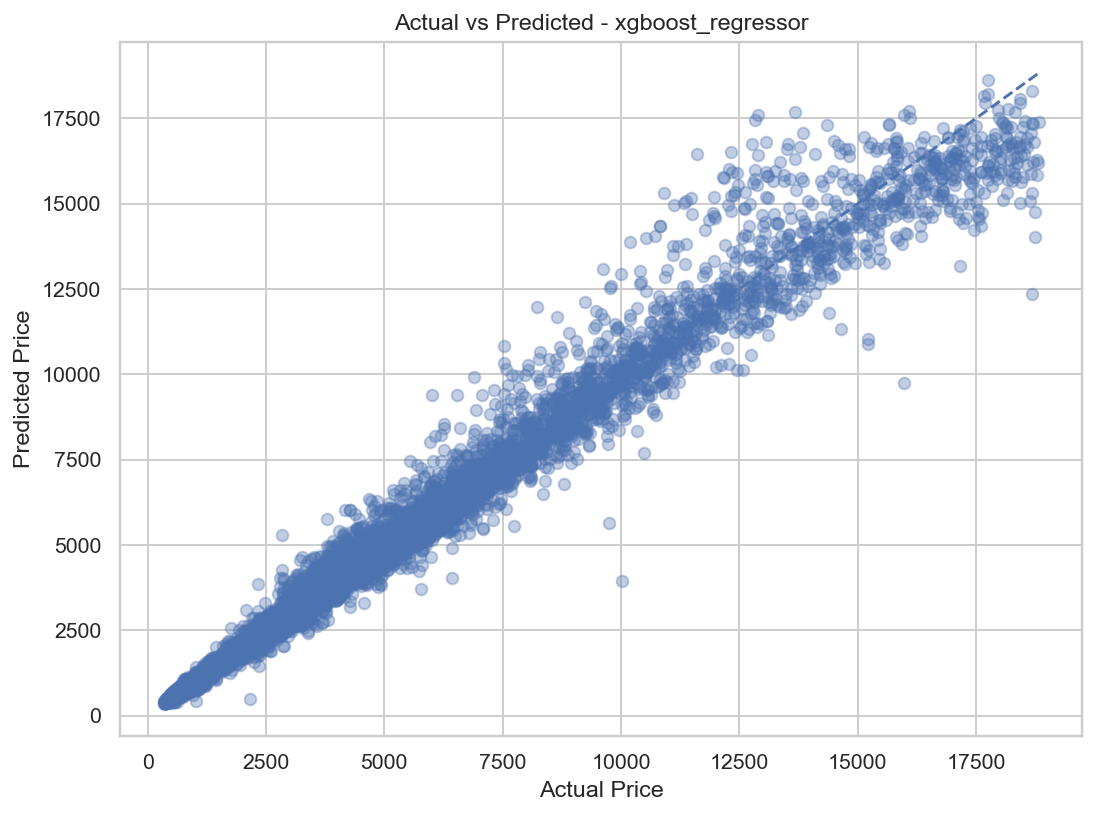

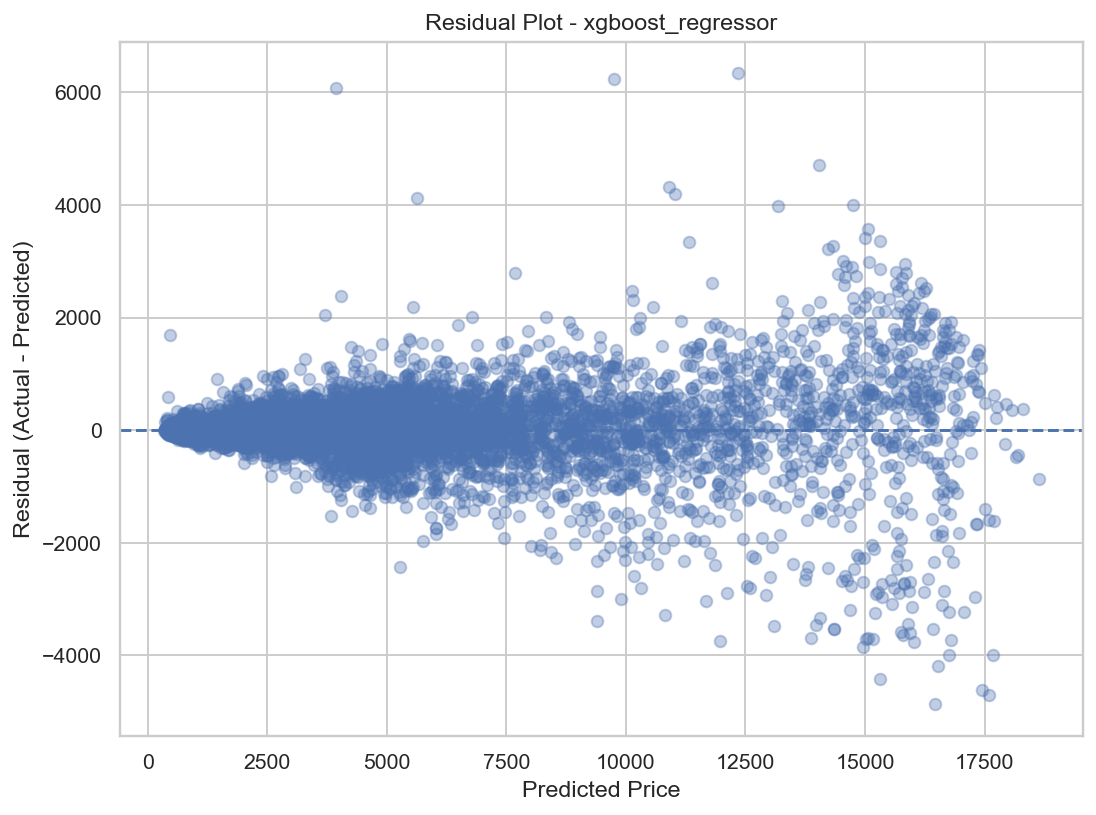

In [11]:
from IPython.display import Image, display

display(Image(filename=str(resolve_project_path(project_root, "figures/regression/regression_models_comparison.png"))))
display(Image(filename=str(resolve_project_path(project_root, "figures/regression/actual_vs_predicted_best_model.png"))))
display(Image(filename=str(resolve_project_path(project_root, "figures/regression/residual_plot_best_model.png"))))

# Display Feature Importance Plot (If Available)

This cell checks whether the winning model supports feature importance and displays the corresponding plot if it exists.

### What is happening
- If the selected best model is tree-based and feature importance was extracted, the notebook loads and displays the feature importance figure.
- If not, a message is shown instead.

### Possible file displayed
- `figures/regression/random_forest_feature_importance.png`

### Why this matters
Feature importance helps explain:
- which features contributed most to prediction,
- whether important raw or engineered features influenced the final model.

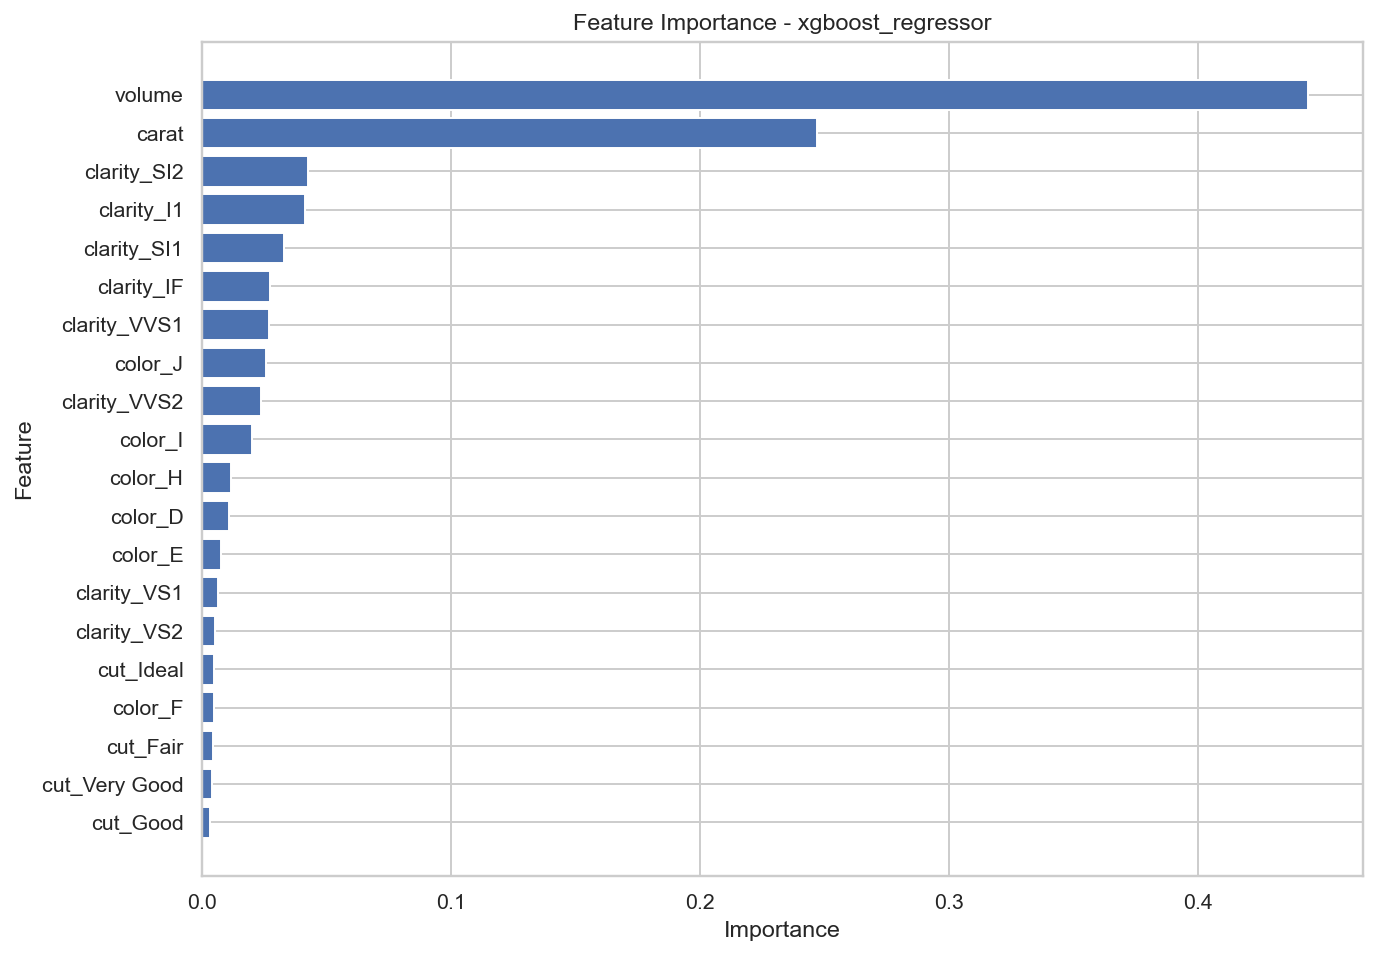

In [12]:
feature_importance_path = resolve_project_path(project_root, "figures/regression/random_forest_feature_importance.png")
if Path(feature_importance_path).exists():
    display(Image(filename = str(feature_importance_path)))
else:
    print("Feature importance plot not created because the selected best model does not expose tree-based feature importance.")